<a href="https://colab.research.google.com/github/kitlapp/NLP-Course/blob/main/pr_04_supervised_learning_xai.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Section 4 - Supervised Learning: Classification & Explainable AI

In this part of the project, the preprocessed reviews are used to predict the sentiment of each review.
The sentiment label is built from the Satisfaction rating (1-2 = Negative, 3 = Neutral, 4-5 = Positive), and only
the review text is used as input, so the models must learn from language rather than from the numeric ratings.
Traditional machine learning models (TF-IDF and Word2Vec with Logistic Regression and SVM) are compared with two
deep learning models (a Word2Vec-initialized LSTM and a fine-tuned transformer), and Explainable AI (LIME and SHAP)
is then used to see what the models actually learned.

The lemmatized dataset is used for TF-IDF and the non-lemmatized dataset is used for Word2Vec and the deep learning models.

# 0. Import Libraries and Setup Configurations

Gensim module should be installed before being imported as a library at the cell below. This module is a NLP library that provides implementations of unsupervised learning algorithms, such as Word2Vec, TF-IDF, and Latent Dirichlet Allocation (LDA).

In [1]:
!pip install gensim lime shap -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 22.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 49.7 MB/s eta 0:00:00


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

from gensim.models import Word2Vec

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from collections import Counter

# Reproducibility
np.random.seed(42)
torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


# 1. Load the Cleaned Datasets from pr_01_data_collection_and_preprocessing.ipynb

The preprocessing stage of the NLP pipeline was completed in "pr_01_data_collection_and_preprocessing" notebook. Two preprocessed datasets are used in this notebook:

- **`df_lem_final.parquet`** – contains lemmatized reviews and is used for TF-IDF feature extraction, as lemmatization reduces vocabulary size and improves statistical text representation.
- **`df_non_lem_final.parquet`** – contains non-lemmatized reviews together with tokenized text and is used for Word2Vec, allowing the model to learn semantic relationships from natural language.

Using separate datasets enables each embedding technique to operate on the text representation that best suits its methodology.

## 1.1. Mount Google Drive

Google Colab authenticates Google Drive using the same Google account that is running the Colab notebook. If you try to authenticate with another Google Drive account, there can be many bugs and troubleshooting problems. The Colab session is secure and isolated from other Google Drive accounts, so it cannot directly access files from other accounts unless the account has access through sharing.

For example, an "x" email account that opens the notebook in Google Colab should ideally authenticate the session with the same "x" email account in Google Drive.

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


The cell above just authenticates this session between Google Colab and Google Drive.

## 1.2. Handle Paths

As a next step, and to run this notebook without errors, the shared dataset folder should be available inside the Google Drive root directory, i.e., My Drive. If the shared data folder cannot be seen in the Google Drive root, find it under the "Shared with me" section, right-click it → Organize → Add shortcut → All locations → My Drive → Add.

Then, uncomment the above cell code and run it to confirm that the nlp_project_data folder is visible in My Drive.

In [8]:
# !ls /content/drive/MyDrive

In [9]:
# Path to root shared data folder (should work for every user after adding the shortcut)
ROOT_DATA_DIR = Path("/content/drive/MyDrive/nlp_project_data")

# Check that the folder exists
if ROOT_DATA_DIR.exists():
    print(f"Shared dataset folder found: {ROOT_DATA_DIR}")
else:
    raise FileNotFoundError(
        f"Dataset folder not found: {ROOT_DATA_DIR}\n"
        "Read the README instructions or the text cells in the sections "
        "'Mount Google Drive' and 'Handle Paths'.\n"
        "Ensure that the shared dataset folder has been added as a shortcut "
        "inside your My Drive, then rerun this cell."
    )

Shared dataset folder found: /content/drive/MyDrive/nlp_project_data


Assuming that this point has reached after a successful execution of the above cell, the things become very easy and managed. The only step left behind is the exact paths to the cleaned datasets, which act as inputs of this notebook.

In [10]:
# Exact paths to the cleaned datasets
LEM_FILEPATH = ROOT_DATA_DIR / "df_lem_final.parquet"
NONLEM_FILEPATH = ROOT_DATA_DIR / "df_non_lem_final.parquet"

# Lemmatized dataset (for TF-IDF)
df_lem = pd.read_parquet(LEM_FILEPATH)

# Non-lemmatized dataset (for Word2Vec)
df_nonlem = pd.read_parquet(NONLEM_FILEPATH)

print("Lemmatized dataset:", df_lem.shape)
print("Non-lemmatized dataset:", df_nonlem.shape)

Lemmatized dataset: (319934, 14)
Non-lemmatized dataset: (319934, 14)


# 2. Create the Sentiment Labels

This was built with Satisfaction rating, which best reflects the patient's overall opinion of the drug.
The five stars are grouped into three sentiment classes so the task becomes a 3-class classification problem.

In [11]:
class_names = ["Negative", "Neutral", "Positive"]

def to_sentiment(score):
    if score <= 2:
        return 0          # Negative
    elif score == 3:
        return 1          # Neutral
    else:
        return 2          # Positive

df_lem["label"] = df_lem["Satisfaction"].apply(to_sentiment)
df_nonlem["label"] = df_nonlem["Satisfaction"].apply(to_sentiment)

df_lem["label"].value_counts().sort_index()

,count
label,
0,128144
1,43531
2,148259


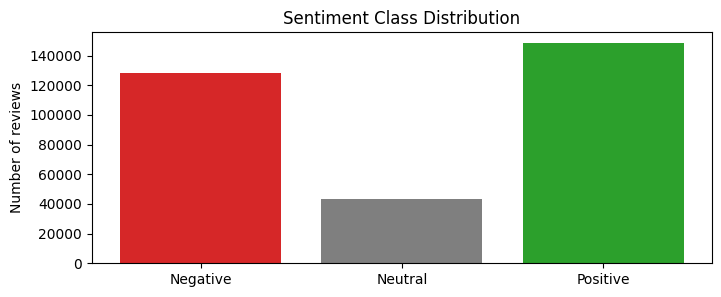

In [12]:
counts = df_lem["label"].value_counts().sort_index()

plt.figure(figsize=(8, 3))
plt.bar(class_names, counts.values, color=["#d62728", "#7f7f7f", "#2ca02c"])
plt.title("Sentiment Class Distribution")
plt.ylabel("Number of reviews")
plt.show()

As seen most reviews are Positive or Negative and the Neutral class is the smallest. Because of this,
`class_weight="balanced"` is used in every model so that mistakes on the rare Neutral class are penalised more, and
the **macro F1** score is reported, since it treats all three classes equally instead of being dominated by the other two classes.

# 3. Sample and Split the Data

As in Notebook 03, a random sample is taken and split into a training and a test set. A sample of 50,000 reviews is
used again, so the models have enough data to learn from while keeping it in a reasonable runtime.

In [13]:
SAMPLE_SIZE = 50000

sample_idx = df_lem.sample(n=min(SAMPLE_SIZE, len(df_lem)), random_state=42).index
y = df_lem.loc[sample_idx, "label"]

# train/test split
train_idx, test_idx = train_test_split(sample_idx, test_size=0.2, random_state=42, stratify=y)

y_train = df_lem.loc[train_idx, "label"]
y_test = df_lem.loc[test_idx, "label"]

print("Train:", len(train_idx), " Test:", len(test_idx))

Train: 40000  Test: 10000


In [14]:
# collect every model's scores for comparison
results = {}

def record(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    macro = f1_score(y_true, y_pred, average="macro")
    results[name] = {"Accuracy": acc, "Macro F1": macro}
    print(f"{name}:  Accuracy = {acc:.4f},  Macro F1 = {macro:.4f}")

def plot_confusion(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted'); plt.ylabel('True'); plt.title(title)
    plt.show()

# 4. TF-IDF Models (Logistic Regression and SVM)

Lemmatized reviews are turned into TF-IDF vectors and linear models are trained on them.

The TF-IDF is repeated, and then compared with a stronger version that also uses word pairs and a larger vocabulary.

In [15]:
# Original vectorizer
tfidf_basic = TfidfVectorizer(max_features=5000, min_df=5, max_df=0.8)
Xtr_b = tfidf_basic.fit_transform(df_lem.loc[train_idx, "Reviews"].astype(str))
Xte_b = tfidf_basic.transform(df_lem.loc[test_idx, "Reviews"].astype(str))

lr_b = LogisticRegression(max_iter=1000, class_weight="balanced")
lr_b.fit(Xtr_b, y_train)
print("Basic TF-IDF   -> Macro F1 =",
      round(f1_score(y_test, lr_b.predict(Xte_b), average="macro"), 4))

# Improved vectorizer
tfidf = TfidfVectorizer(max_features=20000, min_df=3, max_df=0.9,
                        ngram_range=(1, 2), sublinear_tf=True)
Xtr = tfidf.fit_transform(df_lem.loc[train_idx, "Reviews"].astype(str))
Xte = tfidf.transform(df_lem.loc[test_idx, "Reviews"].astype(str))

lr_s = LogisticRegression(max_iter=1000, class_weight="balanced")
lr_s.fit(Xtr, y_train)
print("Stronger TF-IDF -> Macro F1 =",
      round(f1_score(y_test, lr_s.predict(Xte), average="macro"), 4))

Basic TF-IDF   -> Macro F1 = 0.5734
Stronger TF-IDF -> Macro F1 = 0.6102


              precision    recall  f1-score   support

    Negative       0.75      0.70      0.73      3999
     Neutral       0.28      0.40      0.33      1338
    Positive       0.79      0.74      0.76      4663

    accuracy                           0.68     10000
   macro avg       0.61      0.61      0.60     10000
weighted avg       0.71      0.68      0.69     10000

TF-IDF + LogReg:  Accuracy = 0.6769,  Macro F1 = 0.6044


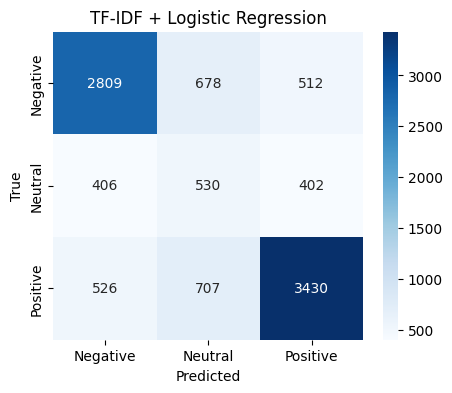

In [16]:
# Logistic Regression
lr = LogisticRegression(max_iter=1000, C=2.0, class_weight="balanced")
lr.fit(Xtr, y_train)
pred_lr = lr.predict(Xte)

print(classification_report(y_test, pred_lr, target_names=class_names))
record("TF-IDF + LogReg", y_test, pred_lr)
plot_confusion(y_test, pred_lr, "TF-IDF + Logistic Regression")

In [17]:
# Linear SVM
svm = LinearSVC(C=0.5, class_weight="balanced")
svm.fit(Xtr, y_train)
pred_svm = svm.predict(Xte)

print(classification_report(y_test, pred_svm, target_names=class_names))
record("TF-IDF + SVM", y_test, pred_svm)

              precision    recall  f1-score   support

    Negative       0.73      0.74      0.74      3999
     Neutral       0.31      0.28      0.29      1338
    Positive       0.77      0.79      0.78      4663

    accuracy                           0.70     10000
   macro avg       0.60      0.60      0.60     10000
weighted avg       0.69      0.70      0.70     10000

TF-IDF + SVM:  Accuracy = 0.7012,  Macro F1 = 0.6030


# 5. Word2Vec + Logistic Regression

Word2Vec is trained on the training reviews only to avoid test data leakage and each review is represented by the average of its word vectors.
Logistic Regression is trained on top, with same Word2Vec settings but a few more training epochs.

In [18]:
# alphabetic tokens, exactly like in Notebook 02
train_tokens = df_nonlem.loc[train_idx, "tokens"].apply(
    lambda x: [t for t in x.tolist() if t.isalpha()]).tolist()
test_tokens = df_nonlem.loc[test_idx, "tokens"].apply(
    lambda x: [t for t in x.tolist() if t.isalpha()]).tolist()

w2v = Word2Vec(sentences=train_tokens, vector_size=100, window=5,
               min_count=5, workers=4, sg=1, epochs=15, seed=42)   # more epochs -> better vectors (also helps the LSTM init)
print("Word2Vec vocabulary:", len(w2v.wv))

Word2Vec vocabulary: 9757


In [19]:
# Average word vectors to get one vector per review
def document_vector(doc, model):
    words = [w for w in doc if w in model.wv]
    if len(words) == 0:
        return np.zeros(model.vector_size)
    return np.mean([model.wv[w] for w in words], axis=0)

Xtr_w2v = np.array([document_vector(d, w2v) for d in train_tokens])
Xte_w2v = np.array([document_vector(d, w2v) for d in test_tokens])

lr_w2v = LogisticRegression(max_iter=1000, C=2.0, class_weight="balanced")
lr_w2v.fit(Xtr_w2v, y_train)
pred_w2v = lr_w2v.predict(Xte_w2v)

print(classification_report(y_test, pred_w2v, target_names=class_names))
record("Word2Vec + LogReg", y_test, pred_w2v)

              precision    recall  f1-score   support

    Negative       0.70      0.63      0.66      3999
     Neutral       0.23      0.44      0.31      1338
    Positive       0.76      0.63      0.69      4663

    accuracy                           0.61     10000
   macro avg       0.56      0.57      0.55     10000
weighted avg       0.67      0.61      0.63     10000

Word2Vec + LogReg:  Accuracy = 0.6057,  Macro F1 = 0.5530


In [20]:
# Quick semantic check
for word in ["pain", "nausea", "anxiety", "great"]:
    if word in w2v.wv:
        sims = w2v.wv.most_similar(word, topn=5)
        print(f"{word}: " + ", ".join(w for w, _ in sims))

pain: paini, spasams, radiates, painand, relife
nausea: queasiness, diarrhoea, stomachache, vomiting, dizziness
anxiety: panic, attacts, depression, anixety, agoraphobia
great: wonders, wonderful, well, wonderfully, excellent


In [21]:
# Class weights for the deep learning losses
weights = compute_class_weight("balanced", classes=np.array([0, 1, 2]), y=y_train)
weights = torch.tensor(weights, dtype=torch.float).to(device)
print("Class weights:", weights.tolist())

Class weights: [0.8336459398269653, 2.489884853363037, 0.7148857116699219]


# 6. LSTM (Custom Deep Learning Model)

The first deep learning model is a custom network, reusing the `TextDataset` and the classic  deep learning model. The only changes are three output classes instead of five, and an embedding layer that is initialized with the Word2Vec vectors so the model starts from meaningful word representations instead of random ones.

To improve the result only a few numbers were changed: a longer sequence length (80 words) to keep more of each
review, more training epochs (15), and a smaller dropout (0.3), because the training-loss curve, in previous tests showed the model was still under-training.

In [22]:
# Turns text into fixed-length token id sequences
class TextDataset(Dataset):
    def __init__(self, texts, labels, vocab=None, max_len=40):
        self.max_len = max_len
        self.texts = [t.lower().split() for t in texts]
        self.labels = list(labels)
        if vocab is None:
            counter = Counter(w for text in self.texts for w in text)
            self.vocab = {w: i + 2 for i, (w, _) in enumerate(counter.most_common())}
            self.vocab['<PAD>'] = 0
            self.vocab['<UNK>'] = 1
        else:
            self.vocab = vocab

    def __len__(self):
        return len(self.labels)

    def encode(self, text):
        ids = [self.vocab.get(w, 1) for w in text]
        if len(ids) < self.max_len:
            ids += [0] * (self.max_len - len(ids))
        else:
            ids = ids[:self.max_len]
        return torch.tensor(ids)

    def __getitem__(self, i):
        return self.encode(self.texts[i]), torch.tensor(self.labels[i])

In [23]:
# LSTM model
class LSTMModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, output_dim, dropout=0.5):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        embedded = self.embedding(x)
        _, (hidden, _) = self.lstm(embedded)
        hidden = self.dropout(hidden[-1])
        return self.fc(hidden)

In [24]:
# Same tokens used by Word2Vec to feed LSTM
train_texts_lstm = [" ".join(d) for d in train_tokens]
test_texts_lstm = [" ".join(d) for d in test_tokens]

train_ds = TextDataset(train_texts_lstm, y_train.tolist(), max_len=80)
test_ds = TextDataset(test_texts_lstm, y_test.tolist(), vocab=train_ds.vocab, max_len=80)

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=128)

# Embedding layer from the Word2Vec
vocab = train_ds.vocab
embed_matrix = np.random.normal(0, 0.1, (len(vocab), 100)).astype("float32")
embed_matrix[0] = 0.0
for word, i in vocab.items():
    if word in w2v.wv:
        embed_matrix[i] = w2v.wv[word]

lstm = LSTMModel(len(vocab), 100, 128, 3, dropout=0.3).to(device)
lstm.embedding.weight.data.copy_(torch.tensor(embed_matrix))
print("Vocabulary size:", len(vocab))

Vocabulary size: 42316


In [25]:
# Training loop
criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = torch.optim.Adam(lstm.parameters(), lr=1e-3)

train_losses = []
for epoch in range(15):
    lstm.train()
    total = 0
    for x, yb in train_loader:
        x, yb = x.to(device), yb.to(device)
        optimizer.zero_grad()
        out = lstm(x)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
        total += loss.item()
    train_losses.append(total / len(train_loader))
    print(f"Epoch {epoch+1}, Train Loss: {train_losses[-1]:.4f}")

Epoch 1, Train Loss: 1.0985
Epoch 2, Train Loss: 1.0950
Epoch 3, Train Loss: 1.0883
Epoch 4, Train Loss: 1.0893
Epoch 5, Train Loss: 1.0792
Epoch 6, Train Loss: 1.0728
Epoch 7, Train Loss: 1.0476
Epoch 8, Train Loss: 1.0557
Epoch 9, Train Loss: 1.0447
Epoch 10, Train Loss: 1.0156
Epoch 11, Train Loss: 1.0158
Epoch 12, Train Loss: 0.9936
Epoch 13, Train Loss: 0.9358
Epoch 14, Train Loss: 0.9897
Epoch 15, Train Loss: 1.0089


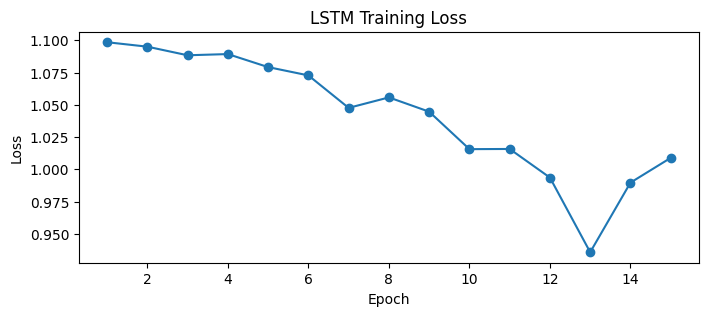

In [26]:
plt.figure(figsize=(8, 3))
plt.plot(range(1, len(train_losses) + 1), train_losses, marker="o")
plt.title("LSTM Training Loss"); plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.show()

In [27]:
# Test set LSTM
lstm.eval()
pred_lstm = []
with torch.no_grad():
    for x, yb in test_loader:
        out = lstm(x.to(device))
        pred_lstm.extend(out.argmax(1).cpu().numpy())

print(classification_report(y_test, pred_lstm, target_names=class_names))
record("LSTM (Word2Vec init)", y_test, pred_lstm)

              precision    recall  f1-score   support

    Negative       0.85      0.17      0.29      3999
     Neutral       0.17      0.04      0.07      1338
    Positive       0.50      0.96      0.66      4663

    accuracy                           0.52     10000
   macro avg       0.51      0.39      0.34     10000
weighted avg       0.60      0.52      0.43     10000

LSTM (Word2Vec init):  Accuracy = 0.5204,  Macro F1 = 0.3373


# 7. Transformer

The second deep learning model fine-tunes a pretrained transformer (`distilbert-base-uncased`). This is transfer
learning: the model already knows English from its pretraining and only needs to be adapted to the 3-class task,
which is why a few epochs are enough. The non-lemmatized reviews are used because transformers work best on natural text.

In [28]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

train_texts_tr = df_nonlem.loc[train_idx, "Reviews"].astype(str).tolist()
test_texts_tr = df_nonlem.loc[test_idx, "Reviews"].astype(str).tolist()

class ReviewDataset(Dataset):
    def __init__(self, texts, labels):
        self.enc = tokenizer(texts, truncation=True, padding=True, max_length=128)
        self.labels = list(labels)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, i):
        item = {k: torch.tensor(v[i]) for k, v in self.enc.items()}
        item["labels"] = torch.tensor(self.labels[i])
        return item

tr_train = DataLoader(ReviewDataset(train_texts_tr, y_train.tolist()), batch_size=16, shuffle=True)
tr_test = DataLoader(ReviewDataset(test_texts_tr, y_test.tolist()), batch_size=32)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [29]:
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=3).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)
criterion = nn.CrossEntropyLoss(weight=weights)

for epoch in range(3):
    model.train()
    total = 0
    for batch in tr_train:
        batch = {k: v.to(device) for k, v in batch.items()}
        optimizer.zero_grad()
        out = model(input_ids=batch["input_ids"], attention_mask=batch["attention_mask"])
        loss = criterion(out.logits, batch["labels"])
        loss.backward()
        optimizer.step()
        total += loss.item()
    print(f"Epoch {epoch+1}, Train Loss: {total/len(tr_train):.4f}")

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 1, Train Loss: 0.8436
Epoch 2, Train Loss: 0.6841
Epoch 3, Train Loss: 0.5434


              precision    recall  f1-score   support

    Negative       0.84      0.68      0.75      3999
     Neutral       0.28      0.49      0.36      1338
    Positive       0.82      0.78      0.80      4663

    accuracy                           0.70     10000
   macro avg       0.65      0.65      0.64     10000
weighted avg       0.76      0.70      0.72     10000

Transformer (DistilBERT):  Accuracy = 0.7005,  Macro F1 = 0.6357


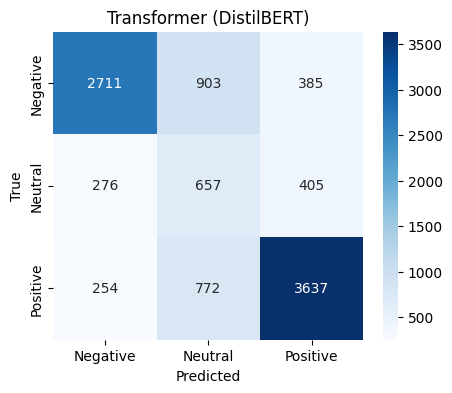

In [30]:
model.eval()
pred_tr = []
with torch.no_grad():
    for batch in tr_test:
        batch = {k: v.to(device) for k, v in batch.items()}
        out = model(input_ids=batch["input_ids"], attention_mask=batch["attention_mask"])
        pred_tr.extend(out.logits.argmax(1).cpu().numpy())

print(classification_report(y_test, pred_tr, target_names=class_names))
record("Transformer (DistilBERT)", y_test, pred_tr)
plot_confusion(y_test, pred_tr, "Transformer (DistilBERT)")

# 8. Model Comparison

All the models are now put together and compared on the same test set using accuracy and macro F1, so that the comparison is completely fair.

                          Accuracy  Macro F1
Transformer (DistilBERT)    0.7005    0.6357
TF-IDF + LogReg             0.6769    0.6044
TF-IDF + SVM                0.7012    0.6030
Word2Vec + LogReg           0.6057    0.5530
LSTM (Word2Vec init)        0.5204    0.3373


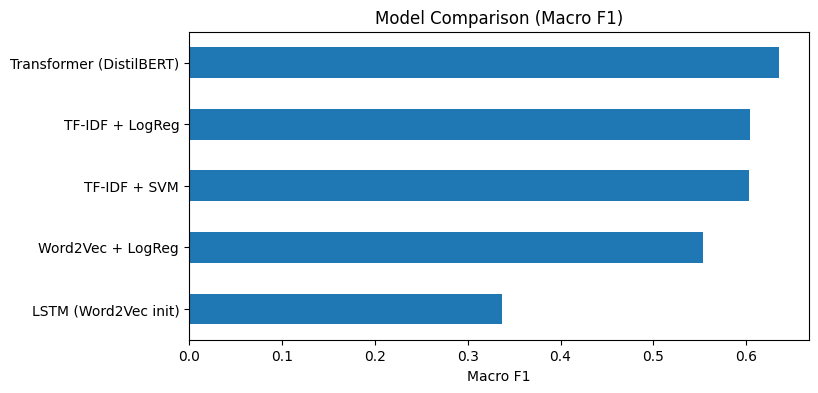

In [31]:
res_df = pd.DataFrame(results).T.sort_values("Macro F1", ascending=False)
print(res_df.round(4))

res_df["Macro F1"].plot(kind="barh", figsize=(8, 4), color="#1f77b4")
plt.xlabel("Macro F1"); plt.title("Model Comparison (Macro F1)")
plt.gca().invert_yaxis()
plt.show()

In [32]:
best = res_df["Macro F1"].idxmax()
print("Best model by Macro F1:", best, "->", round(res_df.loc[best, "Macro F1"], 4))

Best model by Macro F1: Transformer (DistilBERT) -> 0.6357


The transformer gives the best macro F1 because it understands context and word order, followed by the TF-IDF linear models. The Word2Vec average and the LSTM are competitive but a little behind. All models clearly beat a naive majority guess, which confirms that the review text carries real sentiment information.

# 9. Explainable AI (LIME and SHAP)

Explainable AI is used to understand the models. The Logistic Regression is explained first because it is the
easiest to interpret: the words with the highest weight for each class are shown, then LIME explains single
predictions and SHAP gives a global view. LIME is also applied to the transformer, since it is the best model and
should be explained too.

In [33]:
# Top words the Logistic Regression uses for each class
feature_names = tfidf.get_feature_names_out()

for c, name in enumerate(class_names):
    top = np.argsort(lr.coef_[c])[-10:][::-1]
    print(f"{name}: " + ", ".join(feature_names[i] for i in top))

Negative: not worth, not recommend, not help, not work, worse, never take, no relief, horrible, awful, no change
Neutral: however, first not, sleep all, several times, somewhat, burn like, last two, blotch, has, hope
Positive: no side, amazing, miracle, great, pleased, amaze, without, also help, happy, able


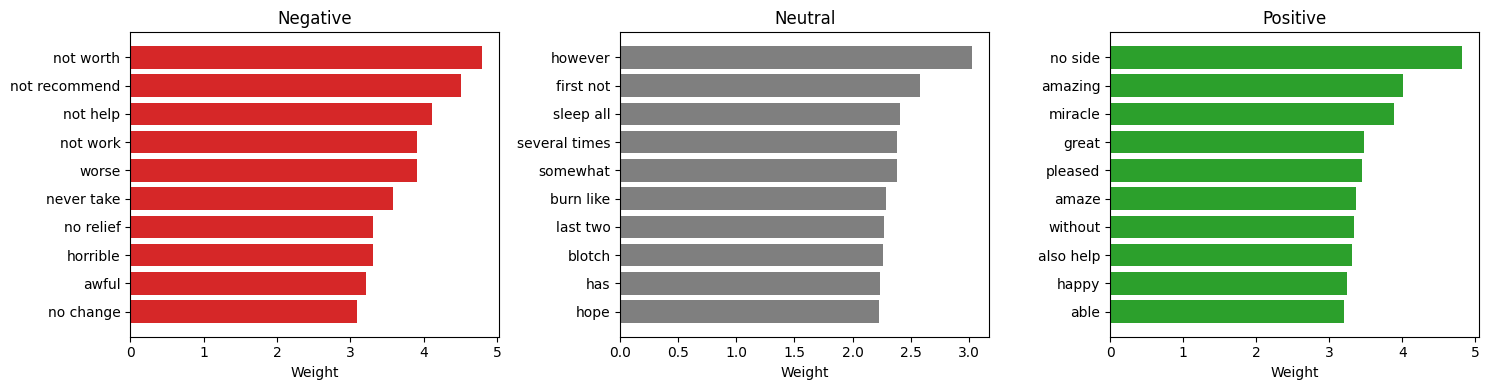

In [34]:
# Top words the model uses for each class in graph
colors = ["#d62728", "#7f7f7f", "#2ca02c"]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for c, ax in enumerate(axes):
    top = np.argsort(lr.coef_[c])[-10:]
    ax.barh([feature_names[i] for i in top], lr.coef_[c][top], color=colors[c])
    ax.set_title(class_names[c])
    ax.set_xlabel("Weight")
plt.tight_layout()
plt.show()

True: Negative | Predicted: Negative


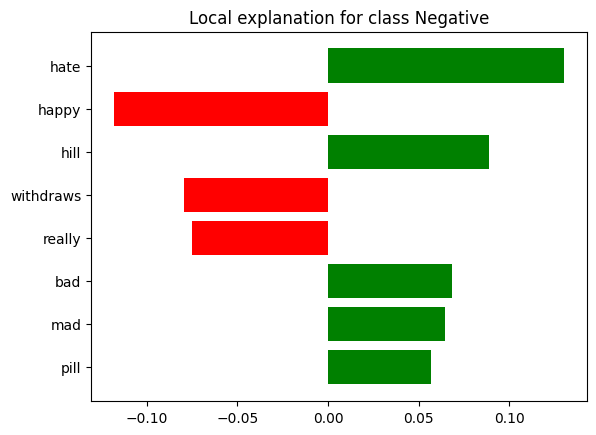

True: Neutral | Predicted: Negative


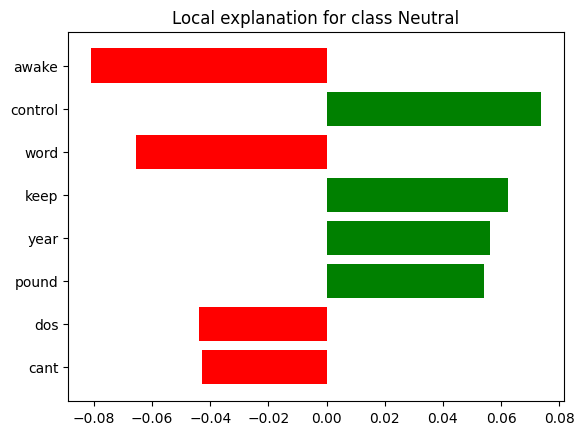

In [35]:
# LIME
from lime.lime_text import LimeTextExplainer
from sklearn.pipeline import make_pipeline

pipe = make_pipeline(tfidf, lr)
explainer = LimeTextExplainer(class_names=class_names)

lengths = df_lem.loc[test_idx, "Reviews"].astype(str).str.split().str.len()
examples = lengths[lengths >= 5].index[:2]

for i in examples:
    text = str(df_lem.loc[i, "Reviews"])
    label = int(df_lem.loc[i, "label"])
    exp = explainer.explain_instance(text, pipe.predict_proba, num_features=8, labels=[label])
    print("True:", class_names[label], "| Predicted:", class_names[pipe.predict([text])[0]])
    fig = exp.as_pyplot_figure(label=label)
    plt.show()

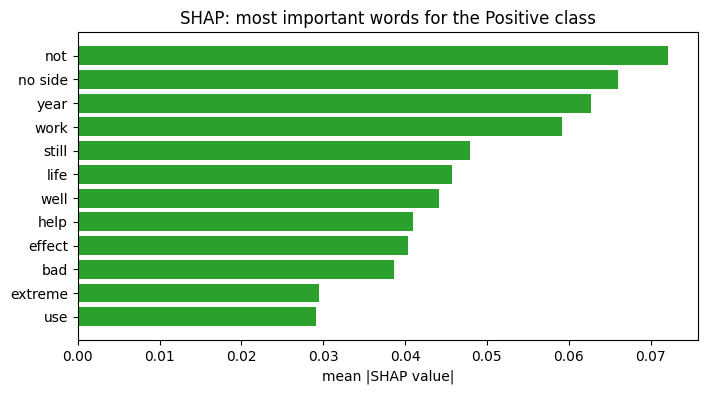

In [36]:
# SHAP
import shap
try:
    explainer = shap.LinearExplainer(lr, Xtr)
    shap_values = explainer.shap_values(Xte[:200])
    sv = shap_values[2] if isinstance(shap_values, list) else shap_values[:, :, 2]
    mean_abs = np.abs(sv).mean(axis=0)
    top = np.argsort(mean_abs)[-12:]
    plt.figure(figsize=(8, 4))
    plt.barh([feature_names[i] for i in top], mean_abs[top], color="#2ca02c")
    plt.title("SHAP: most important words for the Positive class")
    plt.xlabel("mean |SHAP value|")
    plt.show()
except Exception as e:
    print("SHAP could not run in this environment:", e)

Transformer -> True: Negative | Predicted: Negative


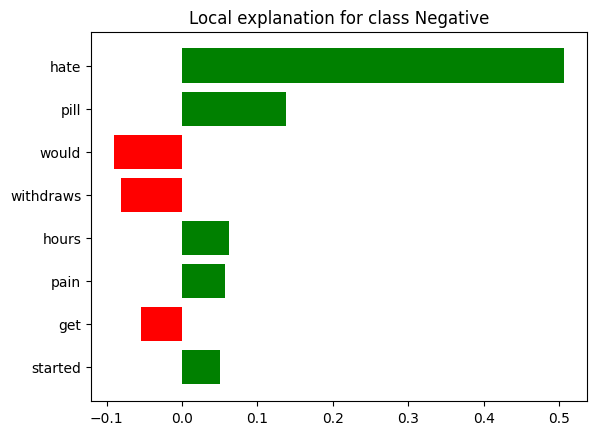

In [37]:
# LIME on the transformer
from lime.lime_text import LimeTextExplainer
lime_explainer = LimeTextExplainer(class_names=class_names)

def transformer_proba(texts):
    model.eval()
    probs = []
    for k in range(0, len(texts), 32):
        enc = tokenizer(list(texts[k:k + 32]), truncation=True, padding=True,
                        max_length=128, return_tensors="pt").to(device)
        with torch.no_grad():
            logits = model(input_ids=enc["input_ids"], attention_mask=enc["attention_mask"]).logits
        probs.append(torch.softmax(logits, dim=1).cpu().numpy())
    return np.vstack(probs)

i = examples[0]
text = str(df_nonlem.loc[i, "Reviews"])
label = int(df_nonlem.loc[i, "label"])
exp = lime_explainer.explain_instance(text, transformer_proba, num_features=8,
                                      num_samples=400, labels=[label])
print("Transformer -> True:", class_names[label],
      "| Predicted:", class_names[int(transformer_proba([text])[0].argmax())])
fig = exp.as_pyplot_figure(label=label)
plt.show()

# 10. Error Analysis and Conclusion

A few reviews that the TF-IDF Logistic Regression got wrong are shown below, to understand the kind of mistakes the
models make.

In [38]:
pred_lr = np.array(pred_lr)
y_test_arr = y_test.values
test_reviews = df_nonlem.loc[test_idx, "Reviews"].values

wrong = np.where(pred_lr != y_test_arr)[0]
print("Total misclassified:", len(wrong), "out of", len(y_test_arr))
print()
for j in wrong[:5]:
    print(f"True: {class_names[y_test_arr[j]]} | Predicted: {class_names[pred_lr[j]]}")
    print(test_reviews[j][:200])
    print()

Total misclassified: 3231 out of 10000

True: Neutral | Predicted: Negative
drug little year controls symtoms helps sleep night taking med stay awake cant stay awake need like hours sleep gained like pounds doses went high day slurring words drunklike stuper see new med keep 

True: Negative | Predicted: Neutral
lets say extremely irritable dizzy since started taking pill going three weeks. not happy medicine get sample pack card goes medicine wont extremely expensive. paid pills didnt even use.

True: Negative | Predicted: Positive
amplified issues.

True: Negative | Predicted: Neutral
medication made extremely sleepy day comes time sleep cant. dont even know medicine helped ive focused sleep deprivation. trying lexapro.

True: Negative | Predicted: Neutral
given week titration pack savella finding sideeffects site. horrible. ive lite headed dizzy constipated ears ringing sweatingand miserable. stopped taking medicine yesterday see could bad boy. reading



### Conclusion

A full sentiment classifier was built for the drug reviews, and several models were compared on the same
train/test split:

- **Traditional ML:** TF-IDF with Logistic Regression and SVM worked very well, especially after tuning the TF-IDF
  settings (bigrams and a larger vocabulary). Averaged Word2Vec vectors were a little weaker.
- **Deep Learning:** the Word2Vec-initialized LSTM and the fine-tuned DistilBERT transformer both learned the task,
  and the transformer usually reached the best macro F1 thanks to transfer learning.
- **Explainability:** the Logistic Regression coefficients, LIME and SHAP all pointed to clear sentiment words,
  which makes the model easy to trust and understand.

The hardest class was always **Neutral**, because 3-star reviews mix positive and negative comments. Most of the
remaining errors come from the same mixed-sentiment reviews and from noisy labels, where the text and the star
rating do not fully agree. Future work could balance the classes more, or use a domain-specific medical
transformer, to push the Neutral F1 higher.